<h1>--------------------------------------------------</h1>
<h1>V. Generation of discrete quantile solar forecasts</h1>
<h1>--------------------------------------------------</h1>

An alternative to ensemble prediction is the generation of discrete estimates of the precitive CDF. This non-parametric method allows defining a predictive CDF without any assumption on the distribution of the future event. The forecast is provided as a set of quantiles spanning the unit
interval. This kind of probabilistic forecast is also called quantile forecasts [1]. For instance, during the the Global Energy Forecasting Competition
2014 (GEFCom 2014) [2], the solar forecasts were to be expressed in the form of 99 quantiles with various nominal proportions between zero
and one. Widely used statistical models, like Quantile Regressions (QR) or Gradient Boosting Decision Trees (GBDT) can estimate these predictive
distributions.

[1] Pinson, P., Nielsen, H. Aa., Møller, J. K., Madsen, H., & Kariniotakis, G. N. (2007). Non-parametric probabilistic forecasts of wind power: Required properties and evaluation. Wind Energy, 10(6), 497–516. https://doi.org/10.1002/we.230

[2] <i>Hong, T., Pinson, P., Fan, S., Zareipour, H., Troccoli, A., & Hyndman, R. J. (2016). Probabilistic energy forecasting: Global Energy Forecasting Competition 2014 and beyond. International Journal of Forecasting, 32(3), 896–913. https://doi.org/10.1016/j.ijforecast.2016.02.001</i>


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import fsspec
from sklearn.linear_model import QuantileRegressor # Linear Model in Quantile Regression (LMQR)
import xgboost as xgb # Gradient Boosting Decision Trees (GBDT)

<h2></h2>
<h1>------------------------------------------------------</h1>
<h1>Post-processing of the ECMWF determinsitic forecasts</h1>

In this Jupyter Notebook, we will generate 2 day-ahead quantile forecast of the Global Horizontal solar Irradiance (GHI) using the raw deterministic ECMWF forecast. We will try 2 different methods, a linear (LMQR) and non-linear (XGBoost) one, to post-process the ECMWF forecast.

<h2>Load and read the data</h2>

The data used in this exercice are publicly available in a GitHub repository of the research lab. PIMENT, University of La Reunion ([Probabilistic_solar_forecast_lesson](https://github.com/Laboratoire-Piment/Probabilistic_solar_forecast_lesson)). If you copy and use this Jupyter Notebook on your computer, adapt the path to the data file.

We will use the NetCDF file containing multiple sources of forecast (NWP, satellite and persistence), the corresponding observations and the clear sky conditions and covering 6 month from July 1st to December 31st 2022. The forecast predict the GHI the university campus of Terre sainte, La Reunion, where high quality solar measurments are available (21.333°S, 51,483°E, 75m, UTC+4h).

In [2]:
# Dowload and copy the required data file from GitHub (https://github.com/Laboratoire-Piment/Probabilistic_solar_forecast_lesson)
# destination = "temp/sat_nwp_pers_1h.nc"
# fs = fsspec.filesystem("github", org="Laboratoire-Piment", repo="Probabilistic_solar_forecast_lesson")
# fs.get("Data/sat_nwp_pers_1h.nc", destination)

# Read and display the file content
ds_det = xr.open_dataset("../Data/sat_nwp_pers_1h.nc")
ds_det

<xarray.Dataset> Size: 10MB
Dimensions:    (step: 48, basetime: 4320)
Coordinates:
  * basetime   (basetime) datetime64[ns] 35kB 2022-07-01T01:00:00 ... 2022-12-28
  * step       (step) timedelta64[ns] 384B 01:00:00 02:00:00 ... 2 days 00:00:00
Data variables:
    GHI_meas   (step, basetime) float64 2MB ...
    GHI_clear  (step, basetime) float64 2MB ...
    zenith     (step, basetime) float64 2MB ...
    GHI_nwp    (step, basetime) float64 2MB ...
    GHI_sat    (step, basetime) float64 2MB ...
    GHI_pers   (step, basetime) float64 2MB ...
Attributes:
    Title:         Aligned GHI forecasts and observations
    Units:         W/m2 for GHI and ° for zenith angle
    Timestamping:  1-hour averages, labeled right (end of interval)
    Description:   GHI forecast from different sources (NWP, satellite and pe...

<h2>Filtering of nigth GHI values</h2>

To build and test the quantile forecast, we will  use only daytime GHI values. Indeed, night GHI is very simple to forecast and taking them into account may introduce a biais while computing the parameters of the forecasting models.

In the rest of the Jupyter notebook, we will only use the filtered dataset.

In [3]:
# Define solar zenith angle threshold
max_zenith = 90

# Create a filtered dataset ds_det_f
ds_det_f = ds_det.where(ds_det['zenith'] <= max_zenith)

<h2>Split the data in training and test set</h2>

In [4]:
# Split into training and test datasets
pct = 0.7 # Percentage of data in the training set

#temporal split
no_samples = len(ds_det_f.basetime)
idx_train = np.arange(int(0.7*no_samples))
idx_test = np.arange(int(0.7*no_samples), no_samples)

ds_train = ds_det_f.isel(basetime=idx_train)
ds_test = ds_det_f.isel(basetime=idx_test)

print('Training dataset period: ', ds_train.basetime.min().values, '-',  ds_train.basetime.max().values)
print('Index range: [', idx_train.min(), ',', idx_train.max(), ']')
print('Test dataset period:  ', ds_test.basetime.min().values, '-',  ds_test.basetime.max().values)
print('Index range: [', idx_test.min(), ',', idx_test.max(), ']')

Training dataset period:  2022-07-01T01:00:00.000000000 - 2022-11-04T00:00:00.000000000
Index range: [ 0 , 3023 ]
Test dataset period:   2022-11-04T01:00:00.000000000 - 2022-12-28T00:00:00.000000000
Index range: [ 3024 , 4319 ]


<h1>------------------------------------------------------</h1>
<h1>Section A: Linear model in quantile regression (LMQR)</h1>

Quantile regression methods provide discrete quantile information about a variable to be forecasted named the predictand. The basic idea of these specific regression methods is to estimate the parameters of functions that link the predictand quantiles with explanatory variables.Various different types of functions have been tested within this framework, such as linear models [1].
A simple method based on linear functions was proposed by Koenker and Bassett [1], which provides the $\tau^{th}$ sample quantile of the variable to be forecast ${y}_{\tau}(t+h)$, as follow:

$$\hat{y}_{\tau}(t+h) = \hat{\beta}_{\tau}x_{nwp}(t+h)$$

In classical regression, the vector of parameters $\hat{\beta}_{\tau}$ is estimated by minimizing the sum of square errors. In quantile regression, conditional quantiles are estimated by applying asymmetric weights to the mean absolute error. Koenker and Bassett [1] described a loss function for achieving this goal as:

$$
\rho_{\tau}(u) = \begin{cases}
    \tau u \text{ if } u \ge 0 \\
    (\tau - 1) u \text{ if } u < 0
\end{cases}
$$

Then, the $\tau^{th}$ sample quantile of ${y}_{\tau}(t+h)$ may be defined through any solution to the following minimization problem:

$$\hat{\beta}_{\tau} = argmin_{\beta} [\sum_{i=1}^N \rho_{\tau}(\beta x (i))]$$

The raw ECMWF-EPS is the GHI ensemble forecast provided by ECMWH without any tranformations.

[1] <i>Koenker, R., & Bassett, G. (1978). Regression Quantiles. Econometrica, 46(1), 33–50. https://doi.org/10.2307/1913643</i>

<h2>Exercice A.1: Train a quantile forecast model using LMQR for a simple case</h2>

Let's start with a simple case to better understand how quantile regression works. To generate the quantile forecast of probability $\tau$ ($\hat{y}_{\tau}$), we will use a unique explanatory variable, the NWP ghi forecast ($x_{nwp}$) and the firts time horizon (1 hour ahead, i.e. h+1). We will estimate the quantile prediction for a set of 11 equidistant cumulative probabilities (i.e. [1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]):
* Train a LMQR on the 11 quantiles for the first forecast horizon and the training set
* Plot the 11 linear quantile functions, the NPW determinsitic forecats of the LMQR along the explanatory variable (i.e. GHI_nwp)
* Change the step and observe the changes in the quantile regression lines

Questions
* Clearly explain what the number of points below and above each line obtained with the quantile linear regression represents.
* Can LMQR lead to a negative GHI?
* Do the lines cross each other?

In [5]:
# Train the linear model on the first horizon (step = 1h)
st = 10
quantiles = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
trained_lin_models = dict()

x_train = ds_train.isel(step=st)[['GHI_nwp']].dropna(dim='basetime').to_array().values.T
y_train = np.squeeze(ds_train.isel(step=st)[['GHI_meas']].dropna(dim='basetime').to_array().values.T)

for q in quantiles:
    lmqr_model = QuantileRegressor(quantile=q, alpha=0)
    lmqr_model.fit(x_train, y_train)
    trained_lin_models[st, q] = lmqr_model

print('Training finished')
print('-------------------------')
for q in quantiles:
  print('Tau:', q, ' / y =', trained_lin_models[st,q].intercept_, '+',
        trained_lin_models[st,q].coef_[0], '* x')

Training finished
-------------------------
Tau: 0.01  / y = -21.008378349433073 + 0.339524409947487 * x
Tau: 0.1  / y = -6.384559865786219 + 0.5914741180264786 * x
Tau: 0.2  / y = -9.558786980194386 + 0.799017080840365 * x
Tau: 0.3  / y = -3.6182233312831906 + 0.9094444960076494 * x
Tau: 0.4  / y = 1.8818099537821014 + 0.9926635168944408 * x
Tau: 0.5  / y = 8.052626219752304 + 1.008176961662347 * x
Tau: 0.6  / y = 14.083053009636103 + 1.022593296180033 * x
Tau: 0.7  / y = 18.86574438476773 + 1.0363226928481812 * x
Tau: 0.8  / y = 31.336752430225875 + 1.0425887752908496 * x
Tau: 0.9  / y = 72.03458436750596 + 1.0328204410963613 * x
Tau: 0.99  / y = 202.26539735573934 + 1.0253722963544107 * x


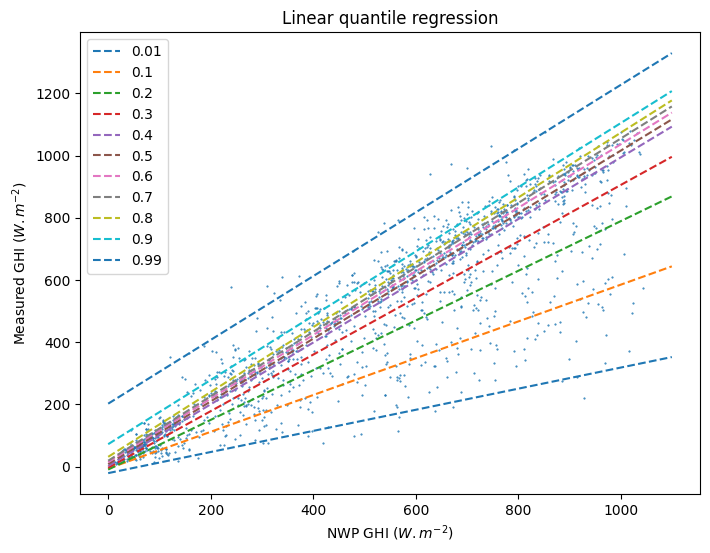

In [6]:
# Plot the linear quantile regression results
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[8, 6])
plt.scatter(x_train, y_train, marker='.', s=1)
x = np.arange(1100)
for q in quantiles :
    y = trained_lin_models[st,q].intercept_ + trained_lin_models[st,q].coef_[0]*x
    plt.plot(x,y, '--', label=q)
plt.ylabel('Measured GHI ($W.m^{-2}$)')
plt.xlabel('NWP GHI ($W.m^{-2}$)')
plt.title('Linear quantile regression')
plt.legend()

<h2>Exercice A.2: Generate probabilsitic forecasts with LMQR</h2>

To avoid crossing quantiles and impossible GHI values, it is very important to reorder the quantiles and to filter negative values after generating the prédictions. To post-process the NWP deterministic and generate the probabilistic forecast:
* Train LMQR on the 11 quantiles for all forecast horizons and the training set
* Generate (predict) the probabilistic forecast for the entire dataset (training + test)
* Reorder the quantiles to obtain the final probabilistic forecast
* Correct negative values of GHI (force to zero)
* Plot a sample of quantile forecasts

Questions
* Why do prediction intervals provide the best visual representation of quantile forecasts?

In [7]:
# Train the linear model
steps = pd.to_timedelta(ds_train.step.data)
quantiles = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
trained_lin_models = dict()

for st in steps:
  print("Step =", st)
  x_train = ds_train.sel(step=st)[['GHI_nwp']].dropna(dim='basetime').to_array().values.T
  y_train = np.squeeze(ds_train.sel(step=st)[['GHI_meas']].dropna(dim='basetime').to_array().values.T)

  for q in quantiles:
      lmqr_model = QuantileRegressor(quantile=q, alpha=0)
      lmqr_model.fit(x_train, y_train)
      trained_lin_models[st, q] = lmqr_model

print('Training finished')

Step = 0 days 01:00:00
Step = 0 days 02:00:00
Step = 0 days 03:00:00
Step = 0 days 04:00:00
Step = 0 days 05:00:00
Step = 0 days 06:00:00
Step = 0 days 07:00:00
Step = 0 days 08:00:00
Step = 0 days 09:00:00
Step = 0 days 10:00:00
Step = 0 days 11:00:00
Step = 0 days 12:00:00
Step = 0 days 13:00:00
Step = 0 days 14:00:00
Step = 0 days 15:00:00
Step = 0 days 16:00:00
Step = 0 days 17:00:00
Step = 0 days 18:00:00
Step = 0 days 19:00:00
Step = 0 days 20:00:00
Step = 0 days 21:00:00
Step = 0 days 22:00:00
Step = 0 days 23:00:00
Step = 1 days 00:00:00
Step = 1 days 01:00:00
Step = 1 days 02:00:00
Step = 1 days 03:00:00
Step = 1 days 04:00:00
Step = 1 days 05:00:00
Step = 1 days 06:00:00
Step = 1 days 07:00:00
Step = 1 days 08:00:00
Step = 1 days 09:00:00
Step = 1 days 10:00:00
Step = 1 days 11:00:00
Step = 1 days 12:00:00
Step = 1 days 13:00:00
Step = 1 days 14:00:00
Step = 1 days 15:00:00
Step = 1 days 16:00:00
Step = 1 days 17:00:00
Step = 1 days 18:00:00
Step = 1 days 19:00:00
Step = 1 da

In [8]:
# Compute probabilistic forecast for the entire dataset (train + test) and night values
lmqr_fcst = np.empty([len(ds_det.basetime.data), len(ds_det.step.data), len(quantiles)])
for cpt,st in enumerate(steps):
    x = ds_det.sel(step=st)[['GHI_nwp']].dropna(dim='basetime').to_array().values.T
    dum = np.empty([len(x),len(quantiles)])
    for i, q in enumerate(quantiles):
        dum[:,i] = trained_lin_models[st, q].predict(x)
        dum[(x == 0)[:,0],i] = 0 # Night values = 0 for all quantiles
    lmqr_fcst[:,cpt,:] = np.sort(dum) # Sort quantiles

lmqr_fcst[lmqr_fcst < 0.0] = 0.0 # Remove negative values

print('Prediction finished')

Prediction finished


In [9]:
# Create a xarray dataset ds_prob, to store generated probabilistic forecast
ds_prob = xr.Dataset(
    {
        'GHI_nwp': (('step', 'basetime'), ds_det['GHI_nwp'].data),
        'GHI_lmqr': (('basetime', 'step', 'quantile'), lmqr_fcst),
        'GHI_meas': (('step', 'basetime'), ds_det['GHI_meas'].data),
        'GHI_clear': (('step', 'basetime'), ds_det['GHI_clear'].data),
        'zenith': (('step', 'basetime'), ds_det['zenith'].data)
    },
    coords={
        'basetime': ('basetime', ds_det.basetime.data),
        'step': ('step', ds_det.step.data),
        'quantile': ('quantile', quantiles)
    }
)

ds_prob = ds_prob.assign_attrs(
    Title='Probabilistic GHI forecasts generated',
    Variables = 'GHI_lmqr: probabilistic GHI forecasts generated with LMQR\n' +
                'GHI_xgboost: probabilistic GHI forecasts generated with xgboost\n' +
                'GHI_nwp: NWP deterministic GHI forecast\n' +
                'GHI_meas: Observed GHI\n' +
                'GHI_clear: Clear sky GHI\n' +
                'zenith: solar zenith angle\n',
    Units = 'W/m**2',
    Timestamping='1-hour GHI, labeled right (end of interval)',
    Horizon='2 days',
    Comment = 'Training period: ' + np.datetime_as_string(ds_train.basetime.min().values, unit='h') + ' / ' +  np.datetime_as_string(ds_train.basetime.max().values, unit='h') + '\n' +
              'Index range: [' + str(idx_train.min()) + ',' + str(idx_train.max()) + ']\n' +
              'Test period: ' + np.datetime_as_string(ds_test.basetime.min().values, unit='h') + ' / ' +  np.datetime_as_string(ds_test.basetime.max().values, unit='h') + '\n' +
              'Index range: [' + str(idx_test.min()) + ',' + str(idx_test.max()) + ']\n'
)

ds_prob

<xarray.Dataset> Size: 25MB
Dimensions:    (step: 48, basetime: 4320, quantile: 11)
Coordinates:
  * basetime   (basetime) datetime64[ns] 35kB 2022-07-01T01:00:00 ... 2022-12-28
  * step       (step) timedelta64[ns] 384B 01:00:00 02:00:00 ... 2 days 00:00:00
  * quantile   (quantile) float64 88B 0.01 0.1 0.2 0.3 0.4 ... 0.7 0.8 0.9 0.99
Data variables:
    GHI_nwp    (step, basetime) float64 2MB 0.0 0.0 68.87 259.7 ... 0.0 0.0 0.0
    GHI_lmqr   (basetime, step, quantile) float64 18MB 0.0 0.0 0.0 ... 0.0 0.0
    GHI_meas   (step, basetime) float64 2MB 0.0 0.3395 44.1 ... 0.0 0.0 0.0
    GHI_clear  (step, basetime) float64 2MB 0.0 0.0 68.54 264.5 ... 0.0 0.0 0.0
    zenith     (step, basetime) float64 2MB 109.6 96.48 83.83 ... 125.3 115.8
Attributes:
    Title:         Probabilistic GHI forecasts generated
    Variables:     GHI_lmqr: probabilistic GHI forecasts generated with LMQR\...
    Units:         W/m**2
    Timestamping:  1-hour GHI, labeled right (end of interval)
    Horizon:       2 days
    Comment:       Training period: 2022-07-01T01 / 2022-11-04T00\nIndex rang...

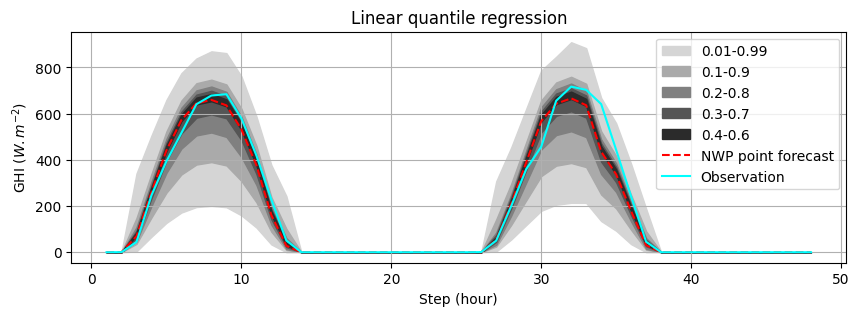

In [10]:
# Pick one basetime and plot a sample
bs = 0 # basetime = 3024, first basetime of the test set

fcst_det = ds_prob.isel(basetime=bs)[['GHI_nwp']].to_array().values.T
fcst_prob = np.squeeze(ds_prob.isel(basetime=bs)[['GHI_lmqr']].to_array().values)
obs = ds_prob.isel(basetime=bs)[['GHI_meas']].to_array().values.T
x = np.arange(ds_prob.step.count())+1

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for quant in np.arange(5):
    lab = str(quantiles[quant]) + '-' + str(quantiles[10-quant])
    plt.fill_between(x, fcst_prob[:,quant], fcst_prob[:,10-quant], color=str((5 - quant) / 6), label=lab)
plt.plot(x, fcst_det, '--', color='red', label='NWP point forecast')
plt.plot(x, obs, '-', color='cyan', label='Observation')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('Linear quantile regression')
plt.grid()
plt.legend()

<h1>------------------------------------------------------</h1>
<h1>Section B: Gradient Boosting Decision Trees</h1>

Boosting is a general approach that can be applied to many statistical learning methods for regression or classification. Here, we restrict its application to the context of decision trees. GBDT builds an ensemble of trees iteratively in order to optimize a specific loss function. In this section we will use the [XGBoost](https://xgboost.readthedocs.io/en/release_3.2.0/) library that implements the machine learning algorithms under the Gradient Boosting framework.

We will use exactly the same approach as for the QLMR. The model has a unique input, the forecast GHI. We train one model per horizon on a set of 11 quantiles ([1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]).

<h2>Exercice B.2: Generate quantile forecast with XGBst</h2>

To generate the forecast with the XGBoost library:
* Train 1 model per horizon (step) using the training set
* Generate (predict) the probabilistic forecast for the entire dataset (training + test)
* Plot a sample of probabilsitic forecast

Questions
* Do you see differences with the LMQR probabilistic forecasts?

In [ ]:
# Train 1 model per horizon
steps = pd.to_timedelta(ds_train.step.data)
quantiles = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

trained_models = dict()

for step in steps:
    print("Step =", step)

    # Extract train data
    x_train = ds_train.sel(step=step)[['GHI_nwp']].dropna(dim="basetime").to_array().values.T
    y_train = np.squeeze(ds_train.sel(step=step)[['GHI_meas']].dropna(dim="basetime").to_array().values.T)

    dtrain = xgb.DMatrix(x_train, label=y_train)

    models_per_quantile = dict()
    for q in quantiles:
        params = {
            "objective": "reg:quantileerror",
            "quantile_alpha": q,
            "max_depth": 4,
            "eta": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "nthread": -1,
            "verbosity": 0
        }
        model = xgb.train(params, dtrain, num_boost_round=200) # The set of hyperparameters is probably suboptimal
        models_per_quantile[q] = model

    trained_models[step] = models_per_quantile
print('Training finished')

In [ ]:
# Compute probabilistic forecast for the entire dataset (train + test) and night values
xgboost_fcst = np.empty([len(ds_det.basetime.data), len(ds_det.step.data), len(quantiles)])
for cpt,step in enumerate(steps):
    x = ds_det.sel(step=step)[['GHI_nwp']].dropna(dim='basetime').to_array().values.T
    models_per_quantile = trained_models[step]
    dum = np.empty([len(x),len(quantiles)])
    for i, q in enumerate(quantiles):
        dum[:,i] = models_per_quantile[q].predict(xgb.DMatrix(x))
        dum[(x == 0)[:,0],i] = 0 # Night values = 0 for all quantiles
    xgboost_fcst[:,cpt,:] = np.sort(dum)

# Add the generated forecast to the xarray datast ds_prob
ds_prob['GHI_xgboost'] = (['basetime', 'step', 'quantile'], xgboost_fcst)

print('Prediction finished')

In [ ]:
# Pick one basetime and plot a sample
bs = 3024 # basetime = 3024, first basetime of the test set

fcst_det = ds_prob.isel(basetime=bs)[['GHI_nwp']].to_array().values.T
fcst_prob = np.squeeze(ds_prob.isel(basetime=bs)[['GHI_xgboost']].to_array().values)
obs = ds_prob.isel(basetime=bs)[['GHI_meas']].to_array().values.T
x = np.arange(ds_prob.step.count())+1

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for quant in np.arange(5):
    lab = str(quantiles[quant]) + '-' + str(quantiles[10-quant])
    plt.fill_between(x, fcst_prob[:,quant], fcst_prob[:,10-quant], color=str((5 - quant) / 6), label=lab)
plt.plot(x, fcst_det, '--', color='red', label='NWP point forecast')
plt.plot(x, obs, '-', color='cyan', label='Observation')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('Gradient Boosting Decision Trees (XGBoost)')
plt.grid()
plt.legend()

<h2>Save and share the resulting probabilistic to evaluate their quality</h2>

In the next Jupyter Notebook ([link here](https://drive.google.com/file/d/1O45AAHpcsywi6vwE3BiJtqwBFK6xG0wF/view?usp=share_link)), we will evaluate the quality of the LMQR and XGBoost. Save and share the dataset ds_prob to be able to use it in the next Jupyter Notebook.

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

ds_prob.to_netcdf('/content/drive/MyDrive/lmqr_xgboost_1h.nc')
# print(os.listdir('/content/drive/MyDrive/')) # List files in the folder '/content/drive/MyDrive/'